# AfriMarket - ANALYSE DES DONNÉES
AfriMarket est une entreprise e-commerce panafricaine opérant dans plusieurs grandes villes 
d’Afrique francophone. Elle vend des produits dans 4 catégories : Électronique, Mode, Beauté, 
Maison 

**Objectif** : Produire une analyse stratégique complète permettant à la direction de prendre des décisions 
business.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Style graphique global : cohérence visuelle (grille, palette, format des nombres) sur tout le notebook
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

def format_milliers(x, pos=None):
    return f"{x:,.0f}".replace(",", " ")

## Chargement des données

In [3]:
base_dir = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
path = base_dir / "data" / "afrimarket_dataset.csv"
data = pd.read_csv(path)

In [4]:
print("les 5 premières lignes du dataset :")
data.head()

les 5 premières lignes du dataset :


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [5]:
print(f"\n Taille des données : {data.shape[0]} lignes et {data.shape[1]} colonnes.")


 Taille des données : 10100 lignes et 14 colonnes.


## Audit & compréhension des données
Objectif : identifier les problèmes de qualité (manquants, doublons, valeurs aberrantes, incohérences de libellés) et documenter les décisions de nettoyage.

In [6]:
# types
print("Vérification des formats colonnes")
data.dtypes

Vérification des formats colonnes


id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object

In [7]:
print("VALEURS MANQUANTES :")
missing = data.isnull().sum()
print(missing[missing > 0] if missing.any() else "Aucune donnée manquante.")

VALEURS MANQUANTES :
Aucune donnée manquante.


In [8]:
print("Nombre de doublons :", data.duplicated().sum())

Nombre de doublons : 100


In [9]:
# Valeurs uniques (catégorielles principales)
for col in ["ville", "categorie", "methode_paiement", "canal_marketing", "statut_commande"]:
    print(f"\n--- {col} ---")
    display(data[col].value_counts(dropna=False).head(20))


--- ville ---


ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
Lomé            735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64


--- categorie ---


categorie
Mode            3005
Électronique    2638
Maison          1948
Beauté          1903
electronique     606
Name: count, dtype: int64


--- methode_paiement ---


methode_paiement
Paiement à la livraison    2561
Mobile Money               2529
Virement                   2508
Carte                      2502
Name: count, dtype: int64


--- canal_marketing ---


canal_marketing
Instagram Ads    4045
Google Ads       2552
Email            2049
Influenceur      1454
Name: count, dtype: int64


--- statut_commande ---


statut_commande
Livrée       9080
retournée     826
Annulée       194
Name: count, dtype: int64

In [10]:
# Détection des anomalies
print("VALEURS ABERANTES :")
print(f"Prix unitaire négatif : {(data['prix_unitaire'] < 0).sum()}")
print(f"Quantité négative ou nulle : {(data['quantite'] <= 0).sum()}")
print(f"Remise négative ou supérieure à 1 : {((data['remise'] < 0 ) | (data['remise'] > 1)).sum()}")

VALEURS ABERANTES :
Prix unitaire négatif : 632
Quantité négative ou nulle : 608
Remise négative ou supérieure à 1 : 614


In [11]:
# Diagnostic approfondi : ces valeurs "négatives" sont-elles de simples erreurs de signe,
# ou des valeurs aberrantes sans rapport avec la vraie donnée ?

# 1) Prix unitaire négatif : la valeur absolue reconstruit-elle un prix plausible ?
neg_price = data[data["prix_unitaire"] < 0]
print("Valeurs négatives de prix_unitaire les plus fréquentes :")
print(neg_price["prix_unitaire"].value_counts().head(5))
print(f"\n-> {(neg_price['prix_unitaire'] == -50.0).sum()} / {len(neg_price)} valeurs négatives valent exactement -50.00")

print("\nComparaison avec le prix réel du même produit (abs(négatif) vs prix positif observé) :")
for p in neg_price["nom_produit"].value_counts().head(3).index:
    prix_reel = data.loc[(data["nom_produit"] == p) & (data["prix_unitaire"] > 0), "prix_unitaire"]
    prix_neg_abs = data.loc[(data["nom_produit"] == p) & (data["prix_unitaire"] < 0), "prix_unitaire"].abs().unique()
    print(f"  {p} : prix réel moyen ≈ {prix_reel.mean():.2f} | abs(prix négatif observé) = {prix_neg_abs}")

# 2) Remise négative : l'inverse tombe-t-il dans la plage réelle des remises ?
neg_remise = data[data["remise"] < 0]["remise"]
pos_remise = data[(data["remise"] >= 0) & (data["remise"] <= 1)]["remise"]
print(f"\nValeurs uniques de remise négative : {neg_remise.unique()}")
print(f"Remises positives observées : min={pos_remise.min()}, médiane={pos_remise.median()}, max={pos_remise.max()}")


Valeurs négatives de prix_unitaire les plus fréquentes :
prix_unitaire
-50.00    610
-17.38      1
-1.81       1
-0.57       1
-1.84       1
Name: count, dtype: int64

-> 610 / 632 valeurs négatives valent exactement -50.00

Comparaison avec le prix réel du même produit (abs(négatif) vs prix positif observé) :
  Produit_Mode_15 : prix réel moyen ≈ 36.94 | abs(prix négatif observé) = [ 0.57 50.  ]
  Produit_Maison_37 : prix réel moyen ≈ 112.38 | abs(prix négatif observé) = [50.]
  Produit_Mode_37 : prix réel moyen ≈ 37.59 | abs(prix négatif observé) = [50.   9.8]

Valeurs uniques de remise négative : [-0.1]
Remises positives observées : min=0.0, médiane=0.1, max=0.3


**Interprétation du diagnostic : pourquoi corriger ici et supprimer là :**

- **Prix unitaire négatif** : ~97% des valeurs négatives valent exactement **-50,00**, quel que soit le produit, un flag/valeur sentinelle sans lien avec le prix réel (ex : un produit qui vaut normalement ~380-400 apparaît à -50). Les rares autres valeurs négatives sont elles aussi décorrélées du prix réel du produit concerné. **Une correction par valeur absolue fabriquerait un prix arbitraire** (ex : 50€ à la place d'un vrai prix inconnu) et biaiserait silencieusement le CA et la marge sur ~6% des commandes. => la donnée est irrécupérable, on **supprime** les lignes plutôt que d'injecter une valeur inventée.

- **Remise négative** : toutes les valeurs négatives valent exactement **-0,10**, mais `abs(-0,10) = 0,10` tombe pile sur la **médiane** des remises réelles (plage observée : 0 à 0,30). Contrairement au prix, la valeur corrigée est statistiquement indiscernable d'une vraie remise. => la donnée est récupérable sans risque de biais, on **corrige** par valeur absolue.

- **Quantité nulle** : les valeurs anormales valent toutes **0** (aucune quantité réellement négative observée), il n'y a pas de signe à inverser, donc pas de correction possible. => **suppression**, comme pour le prix.

**Règle appliquée** : on ne corrige une valeur "négative" que lorsque son inverse est statistiquement plausible au regard de la distribution réelle de la variable (cas de la remise). Dès que l'inverse ne correspond à rien de crédible (cas du prix), on préfère supprimer la ligne plutôt que d'introduire une donnée fabriquée dans les KPIs.

**Décisions de traitement (synthèse) :**
- Suppression des doublons exacts
- Standardisation des dates
- Correction texte : noms des villes (Kinshassa -> Kinshasa), casse/accents des catégories et statuts de commande
- Prix unitaire / quantité anormaux (≤ 0) -> **exclusion** (donnée irrécupérable, voir diagnostic ci-dessus)
- Remise négative -> **correction par valeur absolue** (donnée récupérable, voir diagnostic ci-dessus), puis plafonnée à 1

## Data Cleaning → `df clean`
Objectif : standardiser les champs, corriger les erreurs simples, traiter/remplacer les valeurs aberrantes et produire un dataset exploitable.

In [12]:
df = data.copy()
# Suppression des doublons --
df = df.drop_duplicates()

# --- Standardisation des dates ---
df["date_commande"] = pd.to_datetime(df["date_commande"], errors="coerce")

# --- Uniformisation et correction de texte ---
for col in ['ville', 'categorie', 'statut_commande']:
    df[col] = df[col].str.strip().str.lower().str.capitalize()

df["ville"] = df["ville"].replace({"Kinshassa": "Kinshasa"})
df["categorie"] = df["categorie"].replace({"Électronique": "Electronique", "Beauté": "Beaute"})

# Suppression des lignes avec des prix unitaires négatifs, des quantités négatives ou nulles
df =  df[(df['prix_unitaire'] > 0) & (df['quantite'] > 0)]
# Correction des remises négatives ou supérieures à 1 (et on garde une colonne de contrôle)
df["remise_negative"] = df["remise"] < 0
df['remise'] = df['remise'].abs()  # Convertir les remises négatives en positives
# 'assurer que la remise ne dépasse pas 100%
df['remise'] = df['remise'].clip(upper=1)

df_clean = df.copy()
print("Shape raw:", data.shape)
print("Shape clean:", df_clean.shape)

df_clean.head()

Shape raw: (10100, 14)
Shape clean: (8814, 15)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande,remise_negative
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée,False
1,CMD100001,2025-07-27,C1827,Libreville,Beaute,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée,False
4,CMD100004,2025-11-28,C0003,Libreville,Electronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée,False
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,Virement,Instagram Ads,5.45,Livrée,False
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,0.10,3.59,Virement,Instagram Ads,9.23,Livrée,True


## Feature engineering
Création des variables : `chiffre_affaires`, `marge_brute_estimee`, `profit_net_estime`, `mois`, `indicateur_retour`, `nombre_commandes_par_client`, `clv_simplifiee`.

### Hypothèses de calcul

- **Chiffre d’affaires (CA)** : `prix_unitaire * quantite * (1 - remise)`   
- Les analyses sont faites sur `df_clean` (données filtrées/standardisées).

In [13]:
# Chiffre d'affaires (CA) : Calcul du CA en tenant compte des remises
df_clean['CA'] = (df_clean['prix_unitaire'] * df_clean['quantite']) * (1 - df_clean['remise'])

# Marge brute : Calcul de la marge brute en soustrayant le coût des marchandises vendues du CA
# Supposons un coût de 60% du prix unitaire pour le calcul de la marge brute
df_clean['Marge_Brute'] = df_clean['CA'] - (df_clean['quantite'] * df_clean['prix_unitaire'] * 0.6)

# Profit net estimé : Calcul du profit net en soustrayant les coûts de marketing et de livraison de la marge brute
df_clean['profit_net'] = df_clean['Marge_Brute'] - (df_clean['cout_marketing'] + df_clean['cout_livraison'])

# Extraction du Mois
df_clean['mois'] = df_clean['date_commande'].dt.month_name()

# Indicateur de Retour et annulation (1 si annulé ou retourné, 0 sinon)
df_clean["indicateur_retour"] = (df_clean["statut_commande"] == "Retournée").astype(int)
df_clean["indicateur_annulation"] = (df_clean["statut_commande"] == "Annulée").astype(int)

# Nombre de commandes par clients
df_clean['nombre_commandes_par_client'] = df_clean.groupby('id_client')['id_commande'].transform('count')

# Valeur Vie Client (CLV simplifiée) : Somme des profits par client
df_clean['valeur_vie_client'] = df_clean.groupby('id_client')['profit_net'].transform('sum')

df_clean.head()

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,...,statut_commande,remise_negative,CA,Marge_Brute,profit_net,mois,indicateur_retour,indicateur_annulation,nombre_commandes_par_client,valeur_vie_client
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,...,Livrée,False,138.7188,49.2228,45.7728,December,0,0,23,2212.1050
1,CMD100001,2025-07-27,C1827,Libreville,Beaute,Produit_Beauté_3,37.18,2,0.10,6.89,...,Livrée,False,66.9240,22.3080,7.3780,July,0,0,4,151.5668
4,CMD100004,2025-11-28,C0003,Libreville,Electronique,Produit_Électronique_45,498.71,2,0.02,5.16,...,Livrée,False,977.4716,379.0196,373.3096,November,0,0,25,2626.2725
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,...,Livrée,False,192.1590,64.0530,49.9730,October,0,0,16,909.7160
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,0.10,3.59,...,Livrée,True,62.2080,20.7360,7.9160,July,0,0,14,687.7705


### Sauvegarde du dataset nettoyé
Le dataset nettoyé et enrichi est exporté en CSV.

In [14]:
export_path = base_dir / "data" / "df_clean.csv"
df_clean.to_csv(export_path, index=False)
print(f"Export réalisé : {export_path} ({df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes)")

Export réalisé : c:\Users\latej\Desktop\Projets_github\afrimarket-data-analysis\data\df_clean.csv (8814 lignes, 23 colonnes)


## Analyses exploratoires et visualisations

### CALCUL DES INDICATEURS DE PERFORMANCE GLOBALE

In [15]:
# -----------------------------
# Performance globale (KPI)
# -----------------------------
n_orders = df_clean["id_commande"].nunique()
n_clients = df_clean["id_client"].nunique()

ca_total = df_clean["CA"].sum()
profit_total = df_clean["profit_net"].sum()

# Panier moyen : CA / nb commandes "vente" (livrée + retournée)
nb_sales_orders = df_clean.loc[df_clean["statut_commande"].isin(["Livrée","Retournée"]), "id_commande"].nunique()
panier_moyen = ca_total / nb_sales_orders

taux_annulation = (df_clean["statut_commande"] == "Annulée").mean()
taux_retour = (df_clean["statut_commande"] == "Retournée").mean()

kpi_global = pd.DataFrame({
    "KPI": ["Nb commandes", "Nb clients", "CA total", "Profit net estimé", "Panier moyen", "Taux d'annulation", "Taux de retour"],
    "Valeur": [n_orders, n_clients, ca_total, profit_total, panier_moyen, taux_annulation, taux_retour]
})

display(kpi_global)

,KPI,Valeur
0,Nb commandes,8.814000e+03
1,Nb clients,1.719000e+03
2,CA total,2.384893e+06
3,Profit net estimé,6.674017e+05
4,Panier moyen,2.759334e+02
5,Taux d'annulation,1.940095e-02
6,Taux de retour,8.168822e-02


### ANALYSE PAR CATÉGORIE & ÉVOLUTION MENSUELLE

In [16]:
# Analyse par catégorie
cat_analysis = df_clean.groupby("categorie").agg(
    ca=("CA","sum"),
    marge_brute=("Marge_Brute","sum"),
    profit=("profit_net","sum"),
    taux_retour=("indicateur_retour","mean"),
    nb_commande=("id_commande","nunique")
).sort_values("ca", ascending=False)
cat_analysis['taux_retour'] = cat_analysis['taux_retour'] * 100
cat_analysis

,ca,marge_brute,profit,taux_retour,nb_commande
categorie,,,,,
Electronique,1.773708e+06,592192.2945,554857.4645,13.817664,2808
Maison,3.600604e+05,119679.0652,97036.5752,5.079740,1693
Mode,1.778110e+05,48921.8785,13373.4285,7.469970,2664
Beaute,7.331320e+04,24434.0783,2134.2283,2.850212,1649


**Catégories**
- Électronique : CA ≈ 1,785 M | taux de retour ≈ 13,82% (plus élevé)
- Maison : CA ≈ 0,363 M | retours ≈ 5,08%
- Mode : CA ≈ 0,179 M | retours ≈ 7,47%
- Beauté : CA ≈ 0,074 M | retours ≈ 2,85%

`Conclusion “market”` : Électronique = moteur CA mais principal risque de retours 

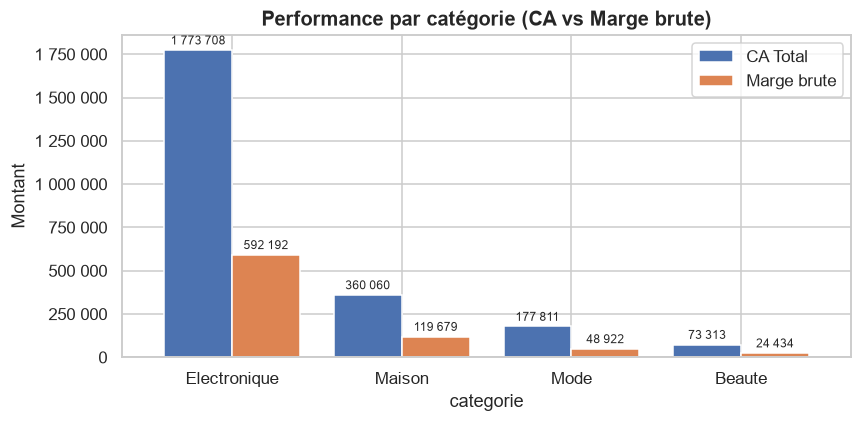

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
cat_analysis.loc[:,['ca','marge_brute']].plot(kind='bar', ax=ax, rot=0, width=0.8)
ax.set_title('Performance par catégorie (CA vs Marge brute)', fontsize=13, fontweight='bold')
ax.set_ylabel('Montant')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
ax.legend(['CA Total', 'Marge brute'])
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v:,.0f}".replace(",", " "), fontsize=8, padding=2)
plt.tight_layout()
plt.show()

In [18]:
# --- Evolution mensuelle CA / profit
ordre_mois = ['July', 'August', 'September', 'October', 'November', 'December']
df_clean['mois'] = pd.Categorical(df_clean['mois'], categories=ordre_mois, ordered=True)
month_evolution = df_clean.groupby('mois').agg(ca=("CA","sum"), profit=("profit_net","sum")).reindex(ordre_mois)
month_evolution

,ca,profit
mois,,
July,372969.6980,103024.5140
August,416284.9465,117700.9705
September,374747.7301,104078.5541
October,415787.7062,117758.7382
November,365790.1219,100775.6839
December,439312.3638,124063.2358


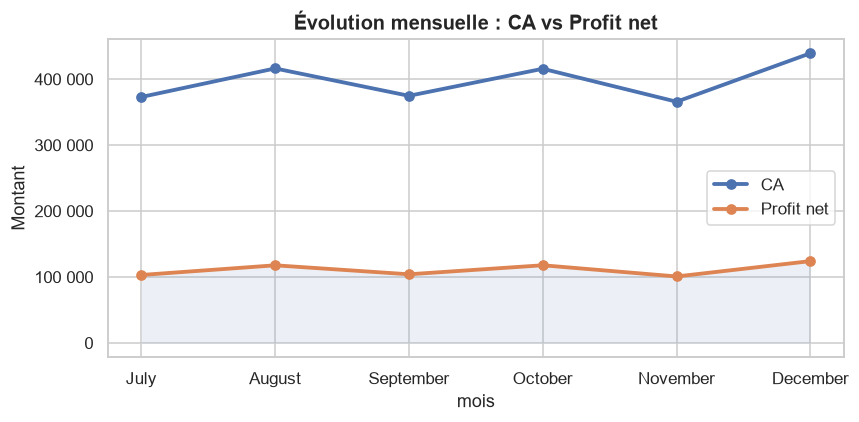

In [19]:
# --- ÉVOLUTION MENSUELLE (CA vs PROFIT NET) ---
fig, ax = plt.subplots(figsize=(8, 4))
month_evolution.plot(kind='line', marker='o', linewidth=2.5, ax=ax)
ax.fill_between(month_evolution.index, month_evolution['profit'], alpha=0.1)
ax.set_title('Évolution mensuelle : CA vs Profit net', fontsize=13, fontweight='bold')
ax.set_ylabel('Montant')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
ax.legend(['CA', 'Profit net'])
plt.tight_layout()
plt.show()

C:\Users\latej\AppData\Local\Temp\ipykernel_7476\4080643521.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


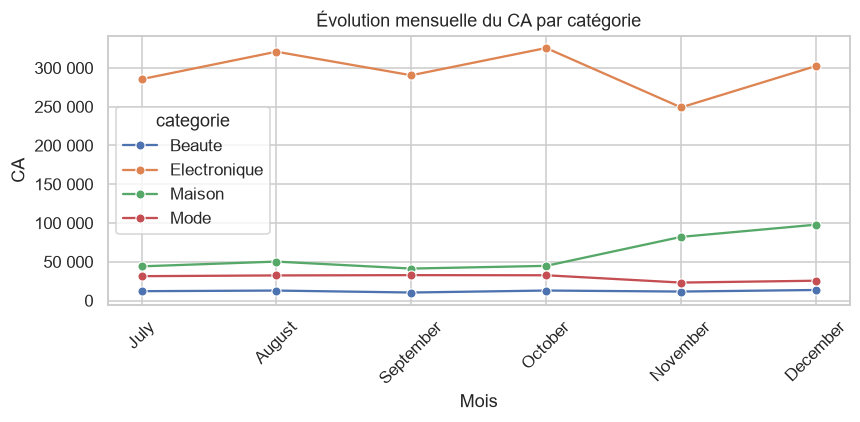

In [20]:
# Évolution mensuelle par catégorie (CA)
cat_month = df_clean.groupby(["mois","categorie"])["CA"].sum().reset_index()
fig, ax = plt.subplots(figsize=(8,4))
sns.lineplot(data=cat_month, x="mois", y="CA", hue="categorie", marker="o", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Évolution mensuelle du CA par catégorie")
ax.set_ylabel("CA")
ax.set_xlabel("Mois")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
plt.tight_layout()
plt.show()

### ANALYSE GÉOGRAPHIQUE

In [21]:
# --- Groupement des données par Ville ---
city_analysis = df_clean.groupby("ville").agg(
    ca=("CA","sum"),
    profit=("profit_net","sum"),
    taux_annulation=("indicateur_annulation","mean"),
    nb_cmd=("id_commande","nunique")
).sort_values("ca", ascending=False)

# Conversion en pourcentage pour la lisibilité
city_analysis['taux_annulation'] = city_analysis['taux_annulation'] * 100
city_analysis

,ca,profit,taux_annulation,nb_cmd
ville,,,,
Kinshasa,703835.8443,197650.2243,0.234742,2556
Abidjan,466889.1974,131335.6974,0.000000,1648
Douala,357464.3049,101037.2309,12.941176,1275
Dakar,320084.3216,89056.9936,0.000000,1255
Lomé,172718.6655,47089.0295,0.000000,641
Cotonou,147718.0720,41150.2180,0.000000,593
Libreville,115438.6419,32656.8759,0.000000,438
Brazzaville,100743.5189,27425.4269,0.000000,408


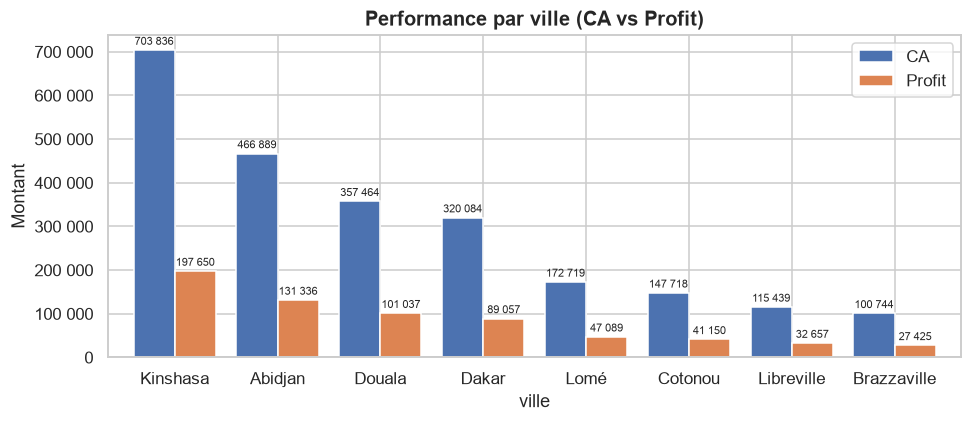

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
city_analysis.loc[:,['ca','profit']].plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Performance par ville (CA vs Profit)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Montant')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
ax.legend(['CA', 'Profit'])
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v:,.0f}".replace(",", " "), fontsize=7, padding=2)
plt.tight_layout()
plt.show()

C:\Users\latej\AppData\Local\Temp\ipykernel_7476\3596815114.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


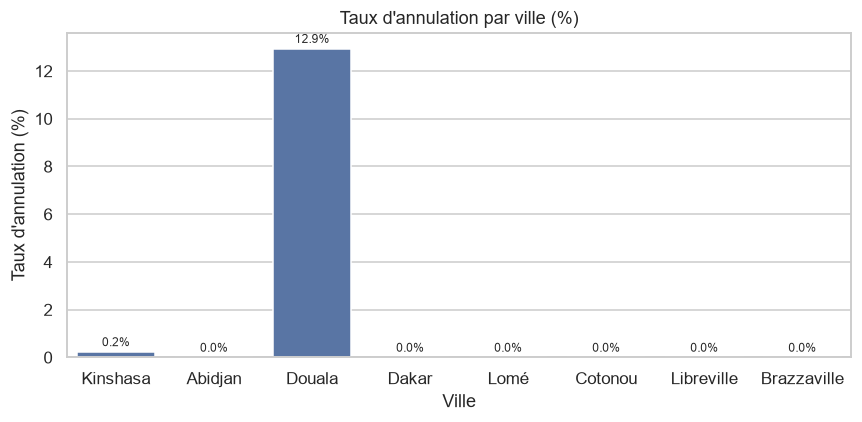

In [23]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=city_analysis.index, y=city_analysis["taux_annulation"].values, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_title("Taux d'annulation par ville (%)")
ax.set_ylabel("Taux d'annulation (%)")
ax.set_xlabel("Ville")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

C:\Users\latej\AppData\Local\Temp\ipykernel_7476\1424966083.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


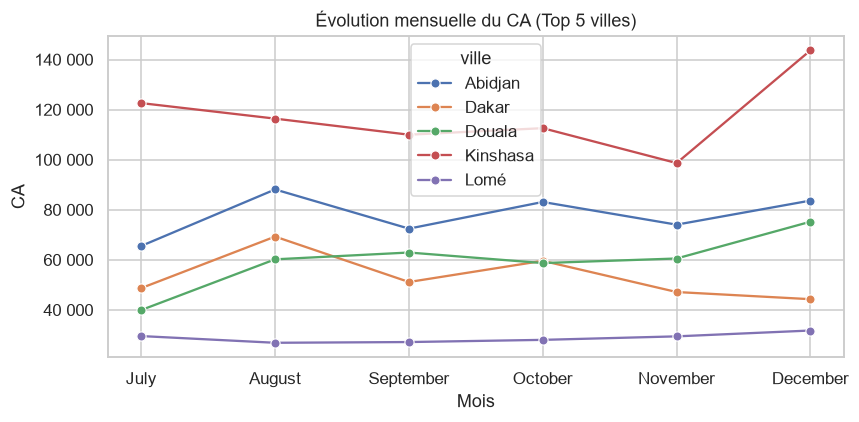

In [24]:
# Croissance mensuelle du CA par ville (top 5)
top_cities = city_analysis.head(5).index.tolist()
city_month = df_clean[df_clean["ville"].isin(top_cities)].groupby(["mois","ville"])["CA"].sum().reset_index()

fig, ax = plt.subplots(figsize=(8,4))
sns.lineplot(data=city_month, x="mois", y="CA", hue="ville", marker="o", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_title("Évolution mensuelle du CA (Top 5 villes)")
ax.set_ylabel("CA")
ax.set_xlabel("Mois")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
plt.tight_layout()
plt.show()

**Top CA (avec signaux)** :

- Kinshasa : CA ≈ 708k | annulation ≈ 0,23%
- Abidjan : CA ≈ 471k | annulation 0%
- Douala : CA ≈ 360k | annulation ≈ 12,94% (très anormal)
- Dakar : CA ≈ 322k | annulation 0%

`Conclusion` : Douala = alerte opérationnelle à auditer en priorité.

### ANALYSE DE LA PERFORMANCE MARKETING

In [25]:
# -----------------------------
# Analyse marketing
# -----------------------------
sales = df_clean[df_clean["statut_commande"].isin(["Livrée","Retournée"])].copy()

mkt = sales.groupby("canal_marketing").agg(
    revenus=("CA","sum"),
    cout_marketing=("cout_marketing","sum"),
    nb_cmd=("id_commande","nunique"),
    nb_clients=("id_client","nunique"),
).sort_values("revenus", ascending=False)

mkt["roi"] = (mkt["revenus"] - mkt["cout_marketing"]) / mkt["cout_marketing"].replace(0, np.nan)
display(mkt)

,revenus,cout_marketing,nb_cmd,nb_clients,roi
canal_marketing,,,,,
Instagram Ads,887802.9805,34626.84,3458,1193,24.639157
Google Ads,619106.4446,12131.21,2207,960,50.034187
Email,503429.9170,2165.69,1749,871,231.457054
Influenceur,327047.9504,14838.04,1229,705,21.041183


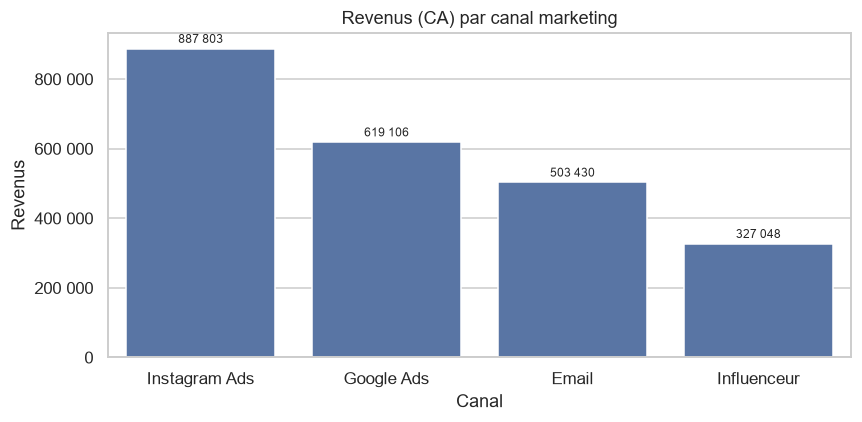

In [26]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=mkt.index, y=mkt["revenus"].values, ax=ax)
ax.set_title("Revenus (CA) par canal marketing")
ax.set_ylabel("Revenus")
ax.set_xlabel("Canal")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v:,.0f}".replace(",", " "), fontsize=8, padding=2)
plt.tight_layout()
plt.show()

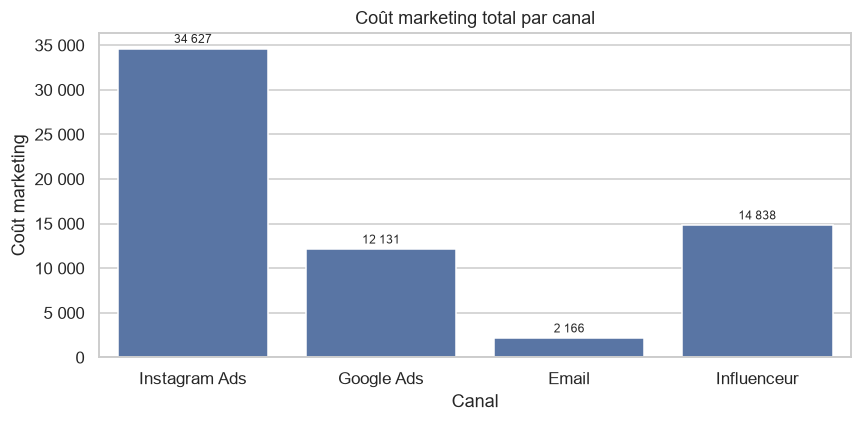

In [27]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=mkt.index, y=mkt["cout_marketing"].values, ax=ax)
ax.set_title("Coût marketing total par canal")
ax.set_ylabel("Coût marketing")
ax.set_xlabel("Canal")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v:,.0f}".replace(",", " "), fontsize=8, padding=2)
plt.tight_layout()
plt.show()

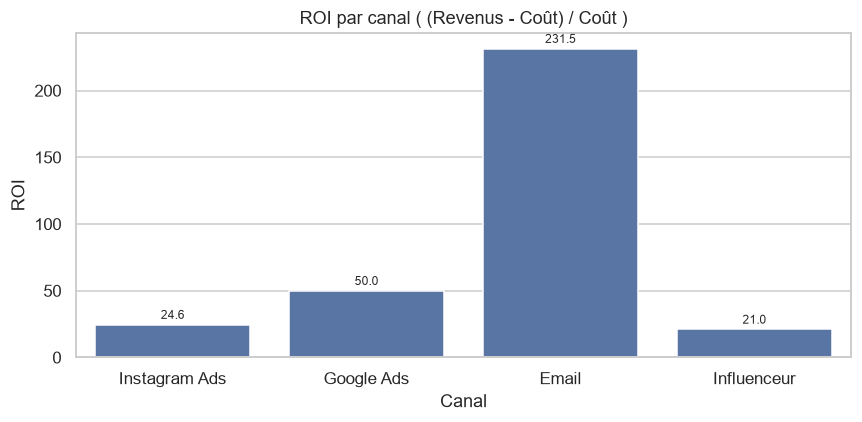

In [28]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=mkt.index, y=mkt["roi"].values, ax=ax)
ax.set_title("ROI par canal ( (Revenus - Coût) / Coût )")
ax.set_ylabel("ROI")
ax.set_xlabel("Canal")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

**Marketing**

- ROI = (CA – coût marketing) / coût marketing
- Email : ROI ≈ 233,45
- Google Ads : ROI ≈ 50,29
- Instagram Ads : ROI ≈ 24,84
- Influenceur : ROI ≈ 21,27

`Conclusion` : Email = “cash machine”, Google Ads = très rentable, Instagram, Influenceur = à optimiser (tracking/qualité audience/offres).

“Le ROI mesure la rentabilité court terme. On le complète par la rétention (qualité des clients acquis) pour éviter de sur-investir dans un canal qui achète du volume peu fidèle.”

In [29]:
# --- Rétention par canal (approche 'first touch' simplifiée) ---
# canal d'acquisition = canal de la première commande du client
first = sales.sort_values("date_commande").groupby("id_client").first()[["canal_marketing", "date_commande"]]
first = first.rename(columns={"canal_marketing":"canal_acquisition", "date_commande":"date_1ere_commande"})

# un client est "récurrent" s'il a >=2 commandes (vente) sur la période
freq = sales.groupby("id_client")["id_commande"].nunique()
is_repeat = (freq >= 2).astype(int).rename("client_recurrent")

ret = pd.concat([first, is_repeat], axis=1).reset_index()
retention = ret.groupby("canal_acquisition").agg(
    nb_clients=("id_client","nunique"),
    taux_retention=("client_recurrent","mean")
).sort_values("nb_clients", ascending=False)

display(retention)

,nb_clients,taux_retention
canal_acquisition,,
Instagram Ads,663,0.696833
Google Ads,413,0.740920
Email,361,0.692521
Influenceur,270,0.748148


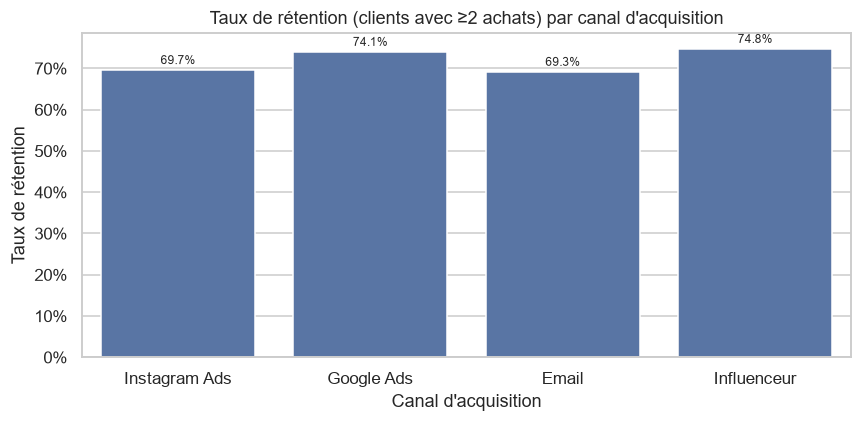

In [30]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=retention.index, y=retention["taux_retention"].values, ax=ax)
ax.set_title("Taux de rétention (clients avec ≥2 achats) par canal d'acquisition")
ax.set_ylabel("Taux de rétention")
ax.set_xlabel("Canal d'acquisition")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v*100:.1f}%", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

**Rétention par canal**

“Rétention calculée en first-touch : canal de la première commande du client ; client retenu si ≥2 commandes (hors annulations).”

- Influenceur : 75,19%
- Google Ads : 74,64%
- Email : 70,89%
- Instagram Ads : 70,63%

`Lecture` : la rétention est globalement élevée sur tous les canaux (bon signal). La différence se joue plutôt sur ROI et coûts => justifie réallocation budgétaire vers Email/Google Ads.

### ANALYSE CLIENTS

In [31]:
# -----------------------------
# Analyse clients
# -----------------------------
sales = df_clean[df_clean["statut_commande"].isin(["Livrée","Retournée"])].copy()

nb_clients = sales["id_client"].nunique()
freq = sales.groupby("id_client")["id_commande"].nunique()
pct_recurrents = (freq >= 2).mean()

print("Nombre total de clients (ayant acheté):", nb_clients)
print("% clients récurrents (≥2 achats):", round(pct_recurrents*100, 2), "%")

Nombre total de clients (ayant acheté): 1707
% clients récurrents (≥2 achats): 71.47 %


In [32]:
# Pareto (80/20) : part du CA portée par les meilleurs clients
ca_client = sales.groupby("id_client")["CA"].sum().sort_values(ascending=False)
pareto = (ca_client.cumsum() / ca_client.sum()).reset_index()
pareto.columns = ["id_client", "part_cumulee_CA"]
pareto["rang"] = np.arange(1, len(pareto)+1)
pareto["part_clients"] = pareto["rang"] / len(pareto)

# % de clients nécessaires pour atteindre 80% du CA
threshold_idx = (pareto["part_cumulee_CA"] >= 0.8).idxmax()
pct_clients_for_80 = pareto.loc[threshold_idx, "part_clients"]

print("Part de clients nécessaires pour 80% du CA:", round(pct_clients_for_80*100, 2), "%")

Part de clients nécessaires pour 80% du CA: 32.04 %


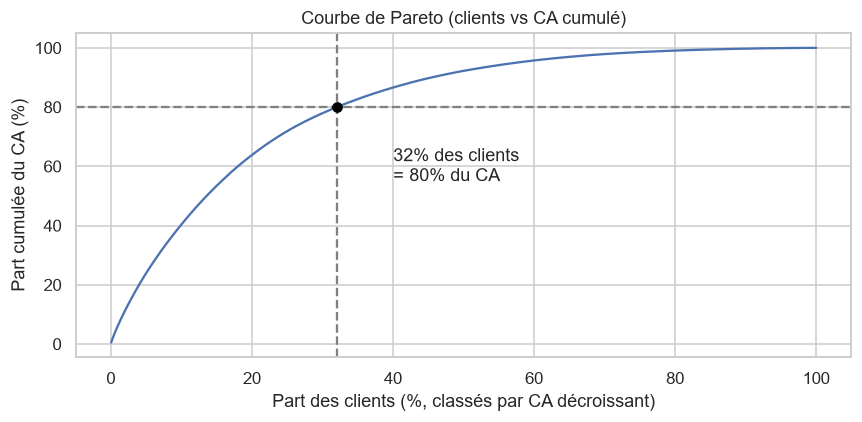

In [33]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(pareto["part_clients"] * 100, pareto["part_cumulee_CA"] * 100)
ax.axhline(80, linestyle="--", color="grey")
ax.axvline(pct_clients_for_80 * 100, linestyle="--", color="grey")
ax.plot([pct_clients_for_80 * 100], [80], "o", color="black")
ax.annotate(
    f"{pct_clients_for_80*100:.0f}% des clients\n= 80% du CA",
    xy=(pct_clients_for_80 * 100, 80),
    xytext=(pct_clients_for_80 * 100 + 8, 55),
)
ax.set_title("Courbe de Pareto (clients vs CA cumulé)")
ax.set_xlabel("Part des clients (%, classés par CA décroissant)")
ax.set_ylabel("Part cumulée du CA (%)")
plt.tight_layout()
plt.show()

In [34]:
# Top 10 clients
top10 = ca_client.head(10).to_frame("CA").reset_index()
top10

,id_client,CA
0,C0157,11553.7392
1,C0266,10673.2270
2,C0120,9240.3449
3,C0114,8915.4355
4,C0051,8646.3990
5,C0067,8476.4071
6,C0003,8437.1465
7,C0364,8252.4673
8,C0054,8044.1152
9,C0379,7948.4510


In [35]:
# Segmentation simple type RFM (recency/frequency/monetary)
snapshot_date = sales["date_commande"].max() + pd.Timedelta(days=1)
rfm = sales.groupby("id_client").agg(
    recency=("date_commande", lambda x: (snapshot_date - x.max()).days),
    frequency=("id_commande","nunique"),
    monetary=("CA","sum")
)

# Scores par quartiles
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1]).astype(int)   # plus récent => meilleur score
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment(row):
    if row["RFM_score"] >= 10:
        return "VIP"
    if row["RFM_score"] >= 8:
        return "Fidèles"
    if row["R_score"] <= 2 and row["F_score"] <= 2:
        return "À réactiver"
    return "Occasionnels"

rfm["segment"] = rfm.apply(segment, axis=1)
seg = rfm["segment"].value_counts().to_frame("nb_clients")
display(seg)

,nb_clients
segment,
À réactiver,597
VIP,475
Fidèles,323
Occasionnels,312


In [36]:
# Poids économique de chaque segment : combien de clients, mais surtout combien de CA/profit
seg_ca = rfm.groupby("segment")["monetary"].sum()
profit_client = sales.groupby("id_client")["profit_net"].sum()
seg_profit = rfm.assign(profit=profit_client).groupby("segment")["profit"].sum()

ordre_segments = ["Occasionnels", "À réactiver", "Fidèles", "VIP"]
seg_summary = pd.DataFrame({
    "nb_clients": seg["nb_clients"],
    "%_clients": (seg["nb_clients"] / seg["nb_clients"].sum() * 100).round(1),
    "CA_cumule": seg_ca.round(2),
    "%_CA": (seg_ca / seg_ca.sum() * 100).round(1),
    "profit_cumule": seg_profit.round(2),
    "%_profit": (seg_profit / seg_profit.sum() * 100).round(1),
}).reindex(ordre_segments)

seg_summary

,nb_clients,%_clients,CA_cumule,%_CA,profit_cumule,%_profit
segment,,,,,,
Occasionnels,312,18.3,98584.72,4.2,23187.05,3.5
À réactiver,597,35.0,211574.90,9.1,58545.03,9.0
Fidèles,323,18.9,317236.44,13.6,91560.16,14.0
VIP,475,27.8,1709991.24,73.2,480491.69,73.5


**Poids économique des segments :**
- **VIP** : 475 clients (27,8% de la base) mais **73,2% du CA et 73,5% du profit** => une minorité de comptes porte l'essentiel de la valeur.
- **Fidèles** : 323 clients (18,9%) => 13,6% du CA.
- **À réactiver** : 597 clients (35,0%, le **groupe le plus nombreux**) => seulement **9,1% du CA** - beaucoup de clients à faible enjeu individuel.
- **Occasionnels** : 312 clients (18,3%) => 4,2% du CA.

`Lecture` : le graphique par nombre de clients seul était trompeur, il donnait l'impression que "À réactiver" était le segment prioritaire (le plus nombreux), alors qu'il pèse le moins en valeur après les Occasionnels. L'enjeu économique réel est concentré sur les 475 VIP : les perdre coûterait bien plus cher que perdre l'ensemble des "À réactiver" et "Occasionnels" réunis, ce qui doit guider l'allocation d'effort CRM (support/rétention VIP en priorité, winback à bas coût pour les segments à faible valeur).

**Actions / recommandations** 

- VIP : avantages + support prioritaire + early access
- Fidèles : bundles / cross-sell / abonnement
- Occasionnels : offre 2e achat + recommandations produits
- À réactiver : winback (coupon limité + nouveautés + relance email)

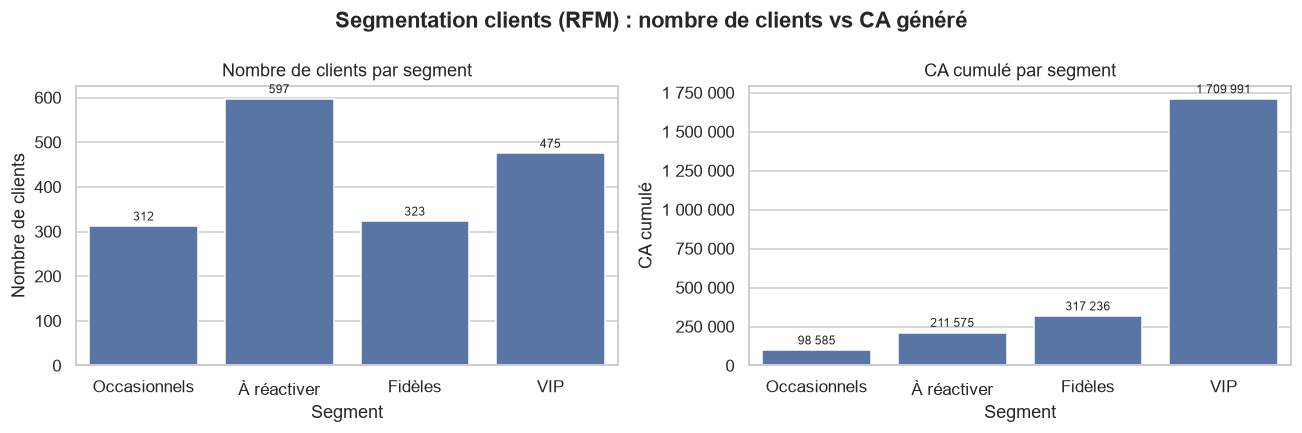

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=seg_summary.index, y=seg_summary["nb_clients"], ax=axes[0])
axes[0].set_title("Nombre de clients par segment")
axes[0].set_ylabel("Nombre de clients")
axes[0].set_xlabel("Segment")
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=8, padding=2)

sns.barplot(x=seg_summary.index, y=seg_summary["CA_cumule"], ax=axes[1])
axes[1].set_title("CA cumulé par segment")
axes[1].set_ylabel("CA cumulé")
axes[1].set_xlabel("Segment")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(format_milliers))
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda v: f"{v:,.0f}".replace(",", " "), fontsize=8, padding=2)

plt.suptitle("Segmentation clients (RFM) : nombre de clients vs CA généré", fontweight="bold")
plt.tight_layout()
plt.show()

## Sauvegarde de la segmentation
Export csv de la segmentation par client (segment RFM, canal d'acquisition, récurrence).

In [38]:
client_export = rfm.reset_index()[["id_client", "recency", "frequency", "monetary", "R_score", "F_score", "M_score", "RFM_score", "segment"]].copy()
client_export = client_export.merge(ret[["id_client", "canal_acquisition", "client_recurrent"]], on="id_client", how="left")
client_export["profit"] = client_export["id_client"].map(profit_client)
client_export = client_export.rename(columns={
    "monetary": "CA",
    "segment": "Segment",
    "canal_acquisition": "CanalAcquisition",
    "client_recurrent": "Recurrent",
})

export_seg_path = base_dir / "data" / "client_segments.csv"
client_export.to_csv(export_seg_path, index=False)
print(f"Export réalisé : {export_seg_path} ({client_export.shape[0]} lignes)")

Export réalisé : c:\Users\latej\Desktop\Projets_github\afrimarket-data-analysis\data\client_segments.csv (1707 lignes)


## Résumé exécutif
Ci-dessous un résumé auto-calculé

In [39]:
# -----------------------------
# Résumé exécutif
# -----------------------------
sales = df_clean[df_clean["statut_commande"].isin(["Livrée","Retournée"])].copy()

best_cat_profit = df_clean.groupby("categorie")["profit_net"].sum().sort_values(ascending=False).head(1)
worst_cat_return = df_clean.groupby("categorie")["indicateur_retour"].mean().sort_values(ascending=False).head(1)

best_city_profit = df_clean.groupby("ville")["profit_net"].sum().sort_values(ascending=False).head(1)

mkt = sales.groupby("canal_marketing").agg(revenus=("CA","sum"), cout=("cout_marketing","sum"))
mkt["roi"] = (mkt["revenus"] - mkt["cout"]) / mkt["cout"].replace(0, np.nan)
best_channel_roi = mkt["roi"].sort_values(ascending=False).head(1)

summary = {
    "CA total": float(ca_total),
    "Profit net estimé": float(profit_total),
    "Panier moyen": float(panier_moyen),
    "Taux annulation": float(taux_annulation),
    "Taux retour": float(taux_retour),
    "Catégorie #1 profit": (best_cat_profit.index[0], float(best_cat_profit.iloc[0])),
    "Catégorie #1 retours (à corriger)": (worst_cat_return.index[0], float(worst_cat_return.iloc[0])),
    "Ville #1 profit": (best_city_profit.index[0], float(best_city_profit.iloc[0])),
    "Canal #1 ROI": (best_channel_roi.index[0], float(best_channel_roi.iloc[0])),
    "Part clients pour 80% CA": float(pct_clients_for_80),
}
summary_df = pd.DataFrame(list(summary.items()), columns=["Indicateur", "Valeur"])
display(summary_df)


,Indicateur,Valeur
0,CA total,2384892.5665
1,Profit net estimé,667401.6965
2,Panier moyen,275.933422
3,Taux annulation,0.019401
4,Taux retour,0.081688
5,Catégorie #1 profit,"(Electronique, 554857.4645)"
6,Catégorie #1 retours (à corriger),"(Electronique, 0.13817663817663817)"
7,Ville #1 profit,"(Kinshasa, 197650.2243)"
8,Canal #1 ROI,"(Email, 231.45705387197614)"
9,Part clients pour 80% CA,0.320445


**Électronique** est le principal moteur de profit mais aussi la principale source de retours. 

**Priorité** : réduire les retours (qualité produit, fiches, packaging, SAV) pour améliorer la marge.

## Conclusion analytique

Sur la période analysée, AfriMarket réalise **2,38M de CA** pour un **profit net estimé de 667k** *(profit = CA - coûts marketing & logistique ; COGS non disponible, donc indicateur de contribution)*. Le **panier moyen** est d’environ **276**, avec un **taux de retour de 8,17%** et un **taux d’annulation de 1,94%**.

Trois enseignements structurants ressortent :
- **Produit** : l’**Électronique** concentre la valeur mais affiche le **taux de retour le plus élevé** => levier prioritaire pour améliorer la marge (qualité, fiches produits, packaging, SAV).
- **Opérations** : **Douala** ressort comme anomalie avec un **taux d’annulation nettement supérieur** => audit logistique/paiement/statuts recommandé.
- **Marketing & CRM** : **Email** présente le **meilleur ROI** et la **rétention par canal** est globalement élevée, ce qui justifie une réallocation progressive vers les canaux les plus rentables tout en pilotant la qualité client. La concentration du CA et la segmentation (VIP/Fidèles/À réactiver) confirment qu’un plan CRM ciblé peut générer des gains rapides.